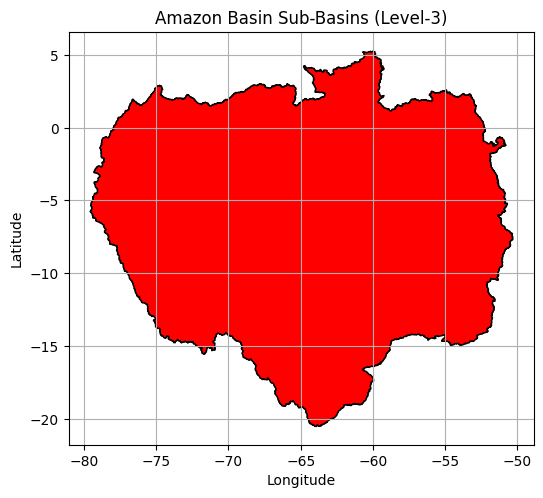

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt

shapefile_path = "../hybas_sa_lev03_v1c.shp"
basins_gdf = gpd.read_file(shapefile_path)

# Filter 
amazon_basins = basins_gdf[basins_gdf['HYBAS_ID'] == 6030007000]  


fig, ax = plt.subplots(figsize=(6, 6))
amazon_basins.plot(ax=ax, color="red", edgecolor="black")
plt.title("Amazon Basin Sub-Basins (Level-3)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(True)
plt.show()

In [2]:
amazon_basins

,HYBAS_ID,NEXT_DOWN,NEXT_SINK,MAIN_BAS,DIST_SINK,DIST_MAIN,SUB_AREA,UP_AREA,PFAF_ID,ENDO,COAST,ORDER,SORT,geometry
6,6030007000,0,6030007000,6030007000,0.0,0.0,5912922.8,5912922.8,622,0,0,1,7,"POLYGON ((-78.43750 -0.68333, -78.43333 -0.683..."


In [2]:
# Specify the path for the new shapefile
output_path = "/home/jai/ERA5_DATA/hybas_sa_lev03_v1c/amazon_basin.shp"

# Save the filtered GeoDataFrame to a new shapefile
amazon_basins.to_file(output_path)


# GRACE

In [3]:
import xarray as xr
import geopandas as gpd
from shapely.geometry import mapping
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

In [4]:
grace = xr.open_dataset('../CSR_GRACE_GRACE-FO_RL0602_Mascons_all-corrections.nc')
grace

<xarray.Dataset>
Dimensions:        (time: 230, timebound: 2, lon: 1440, lat: 720)
Coordinates:
  * time           (time) float32 107.0 129.5 227.5 ... 8.05e+03 8.08e+03
  * lon            (lon) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 ...
    lwe_thickness  (time, lat, lon) float32 ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0602_Mascons_all-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0602M
    subtitle:                   RL06.2 GRACE/GRACE-FO Total water storage wit...
    ...                         ...
    user_note_3:                Ellipsoidal correction has been applied. The ...
    user_note_4:                This GRACE-FO RL06.2 data is an updated versi...
    date_created:               2024-04-25T01:48:44Z
    variable:                   liquid water equivalent thickness
    label:                      RL0602rc24cE
    Mask:                       Global

In [5]:
#Change the time stamp
nctime = grace.variables['time'][:]
origin = pd.Timestamp('2002-01-01')
datetime = pd.to_datetime(nctime, unit='D', origin=origin)
grace['time'] = datetime

mascon_stack=grace.sel(time=slice('2002-01-01','2024-7-31'))
mascon_stack.coords['lon'] = (mascon_stack.coords['lon'] + 180) % 360 - 180
mascon_stack = mascon_stack.sortby(mascon_stack.lon)
mascon_stack

<xarray.Dataset>
Dimensions:        (time: 230, timebound: 2, lon: 1440, lat: 720)
Coordinates:
  * time           (time) datetime64[ns] 2002-04-18 ... 2024-02-15T12:00:00
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 ...
    lwe_thickness  (time, lat, lon) float32 ...
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0602_Mascons_all-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0602M
    subtitle:                   RL06.2 GRACE/GRACE-FO Total water storage wit...
    ...                         ...
    user_note_3:                Ellipsoidal correction has been applied. The ...
    user_note_4:                This GRACE-FO RL06.2 data is an updated versi...
    date_created:               2024-04-25T01:48:44Z
    variable:                   liquid water equivalent thickness
    label:                      RL0602rc24cE
    Mask:                       Global

In [6]:
mascon_stack['lwe_thickness'].values

array([[[-2.7126658 , -2.7126658 , -2.7126658 , ..., -2.7126658 ,
         -2.7126658 , -2.7126658 ],
        [-2.7126658 , -2.7126658 , -2.7126658 , ..., -2.7126658 ,
         -2.7126658 , -2.7126658 ],
        [-1.7623023 , -1.7623023 , -1.7623023 , ..., -1.7623023 ,
         -1.7623023 , -1.7623023 ],
        ...,
        [-2.0677624 , -2.0677624 , -2.0677624 , ..., -2.0677624 ,
         -2.0677624 , -2.0677624 ],
        [-2.62308   , -2.62308   , -2.62308   , ..., -2.62308   ,
         -2.62308   , -2.62308   ],
        [-2.62308   , -2.62308   , -2.62308   , ..., -2.62308   ,
         -2.62308   , -2.62308   ]],

       [[-1.9613819 , -1.9613819 , -1.9613819 , ..., -1.9613819 ,
         -1.9613819 , -1.9613819 ],
        [-1.9613819 , -1.9613819 , -1.9613819 , ..., -1.9613819 ,
         -1.9613819 , -1.9613819 ],
        [-1.3624035 , -1.3624035 , -1.3624035 , ..., -1.3624035 ,
         -1.3624035 , -1.3624035 ],
        ...,
        [-3.9664378 , -3.9664378 , -3.9664378 , ..., -

In [7]:
#Convert the scale from cm to m
mascon_stack['lwe_thickness']=mascon_stack['lwe_thickness']*0.01

#Interpolating the data monthly scale
ds=mascon_stack.resample(time="1MS").mean(dim="time")

ds

<xarray.Dataset>
Dimensions:        (lon: 1440, lat: 720, time: 263, timebound: 2)
Coordinates:
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * time           (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2024-02-01
Dimensions without coordinates: timebound
Data variables:
    time_bounds    (time, timebound) float32 94.0 120.0 ... 8.066e+03 8.095e+03
    lwe_thickness  (time, lat, lon) float32 -0.02713 -0.02713 ... -0.004996
Attributes: (12/59)
    Conventions:                CF-1.6, ACDD-1.3, ISO 8601
    filename:                   netcdf/CSR_GRACE_GRACE-FO_RL0602_Mascons_all-...
    Metadata_Conventions:       Unidata Dataset Discovery v1.0
    standard_name_vocabulary:   NetCDF Climate and Forecast (CF) Metadata Con...
    title:                      CSR GRACE and GRACE-FO MASCON RL0602M
    subtitle:                   RL06.2 GRACE/GRACE-FO Total water storage wit...
    ...                         ...
    user_note_3:                Ellipsoidal correction has been applied. The ...
    user_note_4:                This GRACE-FO RL06.2 data is an updated versi...
    date_created:               2024-04-25T01:48:44Z
    variable:                   liquid water equivalent thickness
    label:                      RL0602rc24cE
    Mask:                       Global

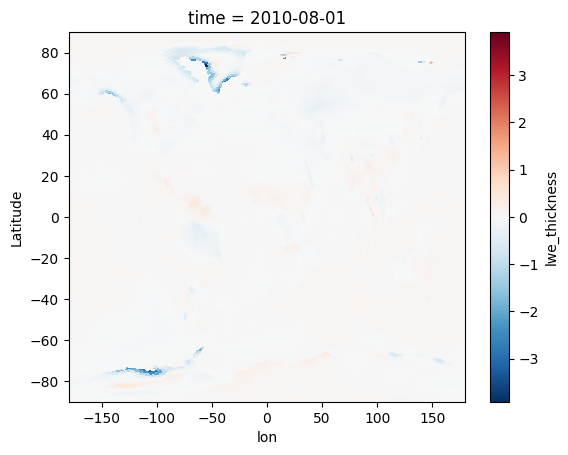

In [9]:
ds.lwe_thickness[100].plot()

In [8]:
##Timeseries
bands = ['lwe_thickness']
ds_bands = ds[bands]
ds_bands.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
ds_bands.rio.write_crs("epsg:4326",inplace=True)

amazon_shp = gpd.read_file('/home/jai/ERA5_DATA/hybas_sa_lev03_v1c/amazon_basin.shp', crs='epsg:4326')
shp_clip = ds_bands.rio.clip(amazon_shp.geometry.apply(mapping), amazon_shp.crs, drop=True)

ds_grid_avg=shp_clip.mean(('lon','lat'))
ds_grid_avg

<xarray.Dataset>
Dimensions:        (time: 263)
Coordinates:
  * time           (time) datetime64[ns] 2002-04-01 2002-05-01 ... 2024-02-01
    spatial_ref    int64 0
Data variables:
    lwe_thickness  (time) float32 0.1719 0.1742 nan ... -0.2154 -0.117 -0.04698

In [11]:
ds_grid_avg['lwe_thickness'].values

array([ 0.17189911,  0.17416221,         nan,         nan, -0.03469684,
       -0.1559715 , -0.21636225, -0.18787584, -0.12930167, -0.09537581,
       -0.00717934,  0.07041806,  0.13246508,  0.14044411,         nan,
        0.03812775, -0.06380706, -0.16007255, -0.187212  , -0.16409706,
       -0.13908432, -0.06795911,  0.0079387 ,  0.07917655,  0.12015818,
        0.1377714 ,  0.0833027 ,  0.0200697 , -0.08078489, -0.15283182,
       -0.17084911, -0.15966533, -0.11710536, -0.06705712,  0.01128654,
        0.10867311,  0.15544689,  0.14417054,  0.0625387 , -0.03910319,
       -0.15434504, -0.22794114, -0.2438979 , -0.22236086, -0.12321632,
        0.00623146,  0.09829136,  0.1537128 ,  0.21439531,  0.1973506 ,
        0.12845533,  0.03137096, -0.08075951, -0.17246275, -0.2005555 ,
       -0.1620177 , -0.0841459 , -0.00425227,  0.03400142,  0.08681931,
        0.15440035,  0.16928548,  0.1165636 ,  0.02267913, -0.09081651,
       -0.20059156, -0.2156933 , -0.17211299, -0.08943418,  0.00

In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


data = {
    'time': ds_grid_avg['time'].values,
    'lwe_thickness': ds_grid_avg['lwe_thickness'].values
}
df = pd.DataFrame(data)
df.loc[df.sample(frac=0.3).index, 'lwe_thickness'] = np.nan  

# Create time features
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month

# Prepare data 
train_df = df.dropna(subset=['lwe_thickness'])
test_df = df[df['lwe_thickness'].isna()]

X_train = train_df[['year', 'month']]
y_train = train_df['lwe_thickness']
X_test = test_df[['year', 'month']]

# Initialize and train the RandomForestRegressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict the NaN values
predicted_values = model.predict(X_test)

# Fill the NaN values in the original dataframe
df.loc[df['lwe_thickness'].isna(), 'lwe_thickness'] = predicted_values

# evaluate the model
y_pred_train = model.predict(X_train)
mse = mean_squared_error(y_train, y_pred_train)
print(f'Mean Squared Error on Training Set: {mse}')


print(df.head())
df = df[['time','lwe_thickness']]


Mean Squared Error on Training Set: 0.0003992544780017154
        time  lwe_thickness  year  month
0 2002-04-01       0.171899  2002      4
1 2002-05-01       0.174162  2002      5
2 2002-06-01       0.096954  2002      6
3 2002-07-01       0.030950  2002      7
4 2002-08-01      -0.034697  2002      8


In [10]:
df.reset_index(drop=True)

,time,lwe_thickness
0,2002-04-01,0.171899
1,2002-05-01,0.174162
2,2002-06-01,0.096954
3,2002-07-01,0.030950
4,2002-08-01,-0.034697
...,...,...
258,2023-10-01,-0.260824
259,2023-11-01,-0.288890
260,2023-12-01,-0.215358
261,2024-01-01,0.000760


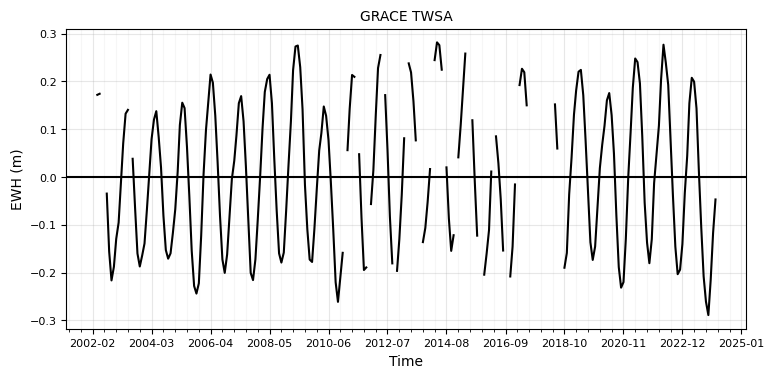

In [11]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ds_grid_avg.time,ds_grid_avg.lwe_thickness,c='black')
ax.set_xlabel("Time")
ax.set_ylabel("EWH (m)")

# Format the date into months & days
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# Change the tick interval
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=25))
plt.gca().xaxis.set_minor_locator(mdates.MonthLocator(interval=5))

# Specify tick label size
ax.tick_params(axis = 'both', which = 'major', labelsize = 8)
ax.tick_params(axis = 'both', which = 'minor', labelsize = 8)

# Specify different settings for major and minor grids
ax.grid(which = 'minor', alpha = 0.1)
ax.grid(which = 'major', alpha = 0.3)
plt.axhline(y = 0.0, color = 'black')

plt.title('GRACE TWSA',fontsize='10')
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15,wspace=0, hspace=0)

plt.show()

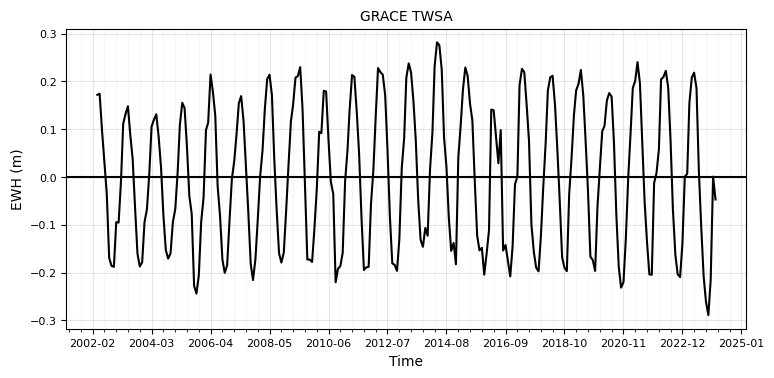

In [12]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd


fig, ax = plt.subplots(figsize=(8, 4))

# Plotting
ax.plot(df['time'], df['lwe_thickness'], c='black')


ax.set_xlabel("Time")
ax.set_ylabel("EWH (m)")

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=25))
ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=5))

ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', labelsize=8)

ax.grid(which='minor', alpha=0.1)
ax.grid(which='major', alpha=0.3)

# Horizontal line at zero
plt.axhline(y=0.0, color='black')


plt.title('GRACE TWSA', fontsize=10)
plt.subplots_adjust(left=0.1, right=0.95, top=0.9, bottom=0.15)

plt.show()


In [13]:
df.set_index('time', inplace=True)
df = df[(df.index >= pd.Timestamp('2003-01-01')) & (df.index <= pd.Timestamp('2022-12-01'))]
ds_interpolated = xr.Dataset.from_dataframe(df.reset_index())
ds_interpolated

<xarray.Dataset>
Dimensions:        (index: 240)
Coordinates:
  * index          (index) int64 0 1 2 3 4 5 6 7 ... 233 234 235 236 237 238 239
Data variables:
    time           (index) datetime64[ns] 2003-01-01 2003-02-01 ... 2022-12-01
    lwe_thickness  (index) float32 -0.09538 -0.007179 0.1115 ... -0.2095 -0.1403

In [16]:
# Convert back to xarray Dataset
# ds_interpolated = xr.Dataset.from_dataframe(df.reset_index())

# Save to NetCDF file
netcdf_path = '../amazone_grace_interpolated_2003_1_2022_12.nc'
ds_interpolated.to_netcdf(path=netcdf_path)

# ERA5

In [15]:
era = xr.open_dataset('../era5_2003_01.nc')
era

<xarray.Dataset>
Dimensions:     (valid_time: 744, latitude: 251, longitude: 301)
Coordinates:
    number      int64 ...
  * valid_time  (valid_time) datetime64[ns] 2003-01-01 ... 2003-01-31T23:00:00
  * latitude    (latitude) float64 5.0 4.9 4.8 4.7 ... -19.7 -19.8 -19.9 -20.0
  * longitude   (longitude) float64 -80.0 -79.9 -79.8 ... -50.2 -50.1 -50.0
    expver      (valid_time) object ...
Data variables:
    ro          (valid_time, latitude, longitude) float32 ...
    ssro        (valid_time, latitude, longitude) float32 ...
    sro         (valid_time, latitude, longitude) float32 ...
    e           (valid_time, latitude, longitude) float32 ...
    tp          (valid_time, latitude, longitude) float32 ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2024-11-08T10:09 GRIB to CDM+CF via cfgrib-0.9.1...

In [19]:
era['ro'].values

array([[[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        ...,
        [           nan,            nan,            nan, ...,
         2.27540731e-05, 3.49879265e-05, 4.63873148e-05],
        [           nan,            nan,            nan, ...,
         2.91764736e-05, 1.98185444e-06, 2.35885382e-05],
        [           nan,            nan,            nan, ...,
         3.23355198e-05, 2.65985727e-05, 3.04877758e-05]],

       [[           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan, 

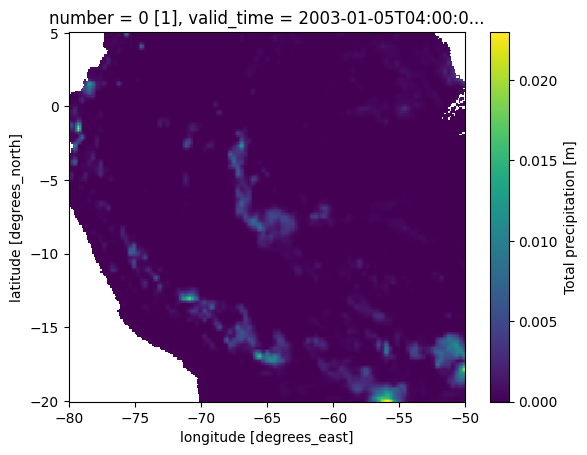

In [20]:
era.tp[100].plot()

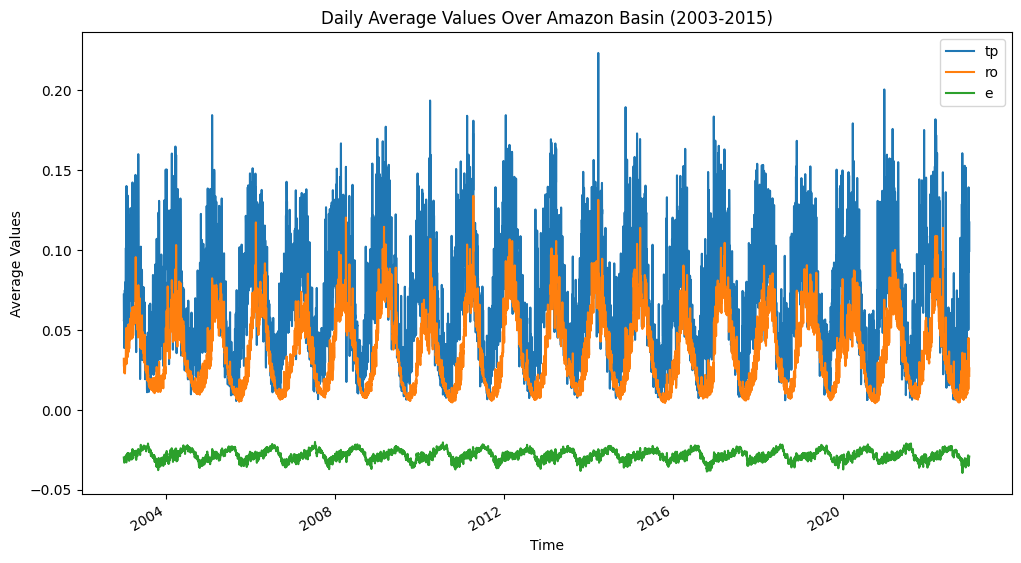

In [19]:

# Load all NetCDF files from 2003-01 to 2022-12
era = xr.open_mfdataset('../era5_20??_??.nc', combine='by_coords')

# Load the Amazon basin shapefile
amazon_shp = gpd.read_file('../amazon_basin.shp', crs='epsg:4326')

# Variables to process
variables = ['tp', 'ro', 'e']
results = []

for var in variables:
    ds_bands = era[var]
    ds_bands.rio.set_spatial_dims(x_dim="longitude", y_dim="latitude", inplace=True)
    ds_bands.rio.write_crs("epsg:4326", inplace=True)

    # Resample hourly data to daily data
    daily_ds_bands = ds_bands.resample(valid_time='1D').sum()
    
    # Clip to the shape of the Amazon basin and calculate daily averages over the spatial dimensions
    shp_clip = daily_ds_bands.rio.clip(amazon_shp.geometry.apply(mapping), amazon_shp.crs, drop=True)
    ds_grid_avg = shp_clip.mean(('longitude', 'latitude'))
    results.append(ds_grid_avg)

# Combine results into one dataset
combined_ds = xr.concat(results, dim='variable')
combined_ds['variable'] = variables

# Save to NetCDF
combined_ds.to_netcdf('../combined_2003_2022.nc')

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))
for i, var in enumerate(variables):
    combined_ds.sel(variable=var).plot(ax=ax, label=var)

ax.set_title('Daily Average Values Over Amazon Basin (2003-2015)')
ax.set_xlabel('Time')
ax.set_ylabel('Average Values')
ax.legend()

plt.show()